In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.NOUS_RESEARCH_HERMES_2_PRO_LLAMA_3_8B
# model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)


local_llm = ChatOpenAI(
    api_key=settings.LMSTUDIO_API_KEY.get_secret_value(),
    base_url=settings.LMSTUDIO_URL,
    temperature=0.0,
    model=model_str_local,
)

## Create State Schema

### Using TypedDict

- State Schema defines the structure of the state that will be used by the graph.

In [5]:
from typing import TypedDict

# SportType: TypeAlias = Literal["football", "basketball"]
type SportType = Literal["football", "basketball"]


class State(TypedDict):
    name: str
    game: SportType

### Create Nodes

In [6]:
def play_sports(state: State) -> dict[str, Any]:
    print("`Play Sports Game` node executed.")
    return {"name": state["name"] + " wants to play"}


def football(state: State) -> dict[str, Any]:
    print("`Play Football` node executed.")
    return {"name": state["name"] + " football!", "game": "football"}


def basketball(state: State) -> dict[str, Any]:
    print("`Play Basketball` node executed.")
    return {"name": state["name"] + " basketball!", "game": "basketball"}

#### Conditional Node

In [7]:
import random


def choose_game(state: State) -> SportType:
    """
    Using Literal["football", "basketball"] directly instead of SportType
    allows LangGraph to properly introspect the possible return values
    for graph visualization with conditional edges.
    """
    print("`Choose Game` node executed")
    if random.random() < 0.5:
        return "football"

    return "basketball"

In [8]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

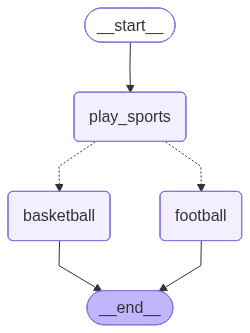

In [9]:
builder: StateGraph = StateGraph(State)

# Create Nodes
builder.add_node("play_sports", play_sports)
builder.add_node("football", football)
builder.add_node("basketball", basketball)

# Create Edges
builder.add_edge(START, "play_sports")
builder.add_conditional_edges(
    "play_sports",
    choose_game,
    {
        "football": "football",
        "basketball": "basketball",
    },
)
builder.add_edge("football", END)
builder.add_edge("basketball", END)

# Build
graph = builder.compile()

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [10]:
graph.invoke({"name": "Neidu"})

`Play Sports Game` node executed.
`Choose Game` node executed
`Play Football` node executed.


{'name': 'Neidu wants to play football!', 'game': 'football'}

### Using Dataclasses

- It uses the `dot` notation.

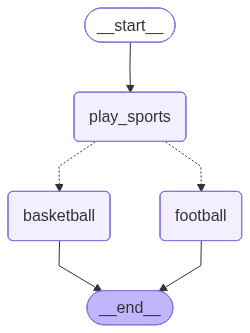

In [11]:
from dataclasses import dataclass


@dataclass
class State:
    name: str
    game: SportType | None = None


def play_sports(state: State) -> dict[str, Any]:
    print("`Play Sports Game` node executed.")
    return {"name": state.name + " wants to play"}  # dot notation


def football(state: State) -> dict[str, Any]:
    print("`Play Football` node executed.")
    return {"name": state.name + " football!", "game": "football"}  # dot notation


def basketball(state: State) -> dict[str, Any]:
    print("`Play Basketball` node executed.")
    return {"name": state.name + " basketball!", "game": "basketball"}  # dot notation


def choose_game(state: State) -> SportType:
    """
    Using Literal["football", "basketball"] directly instead of SportType
    allows LangGraph to properly introspect the possible return values
    for graph visualization with conditional edges.
    """
    print("`Choose Game` node executed")
    if random.random() < 0.5:
        return "football"

    return "basketball"


builder: StateGraph = StateGraph(State)

# Create Nodes
builder.add_node("play_sports", play_sports)
builder.add_node("football", football)
builder.add_node("basketball", basketball)

# Create Edges
builder.add_edge(START, "play_sports")
builder.add_conditional_edges(
    "play_sports",
    choose_game,
    {
        "football": "football",
        "basketball": "basketball",
    },
)
builder.add_edge("football", END)
builder.add_edge("basketball", END)

# Build
graph = builder.compile()

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [12]:
graph.invoke(State(name="Dave"))

`Play Sports Game` node executed.
`Choose Game` node executed
`Play Basketball` node executed.


{'name': 'Dave wants to play basketball!', 'game': 'basketball'}

## Chains

In [14]:
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage

In [15]:
messages: list[AnyMessage] = [
    AIMessage(content="Hello, how are you?"),
    HumanMessage(content="I am fine, thank you!"),
    AIMessage(content="What can I do for you today?"),
    HumanMessage(content="Can you help me with learning about AI Agents?"),
    AIMessage(
        content="Of course! AI Agents are autonomous programs that can perform tasks on behalf of users."
    ),
]

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================

Hello, how are you?
================================ Human Message =================================

I am fine, thank you!
================================== Ai Message ==================================

What can I do for you today?
================================ Human Message =================================

Can you help me with learning about AI Agents?
================================== Ai Message ==================================

Of course! AI Agents are autonomous programs that can perform tasks on behalf of users.


## Chat Models

In [17]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.GEMINI_2_0_FLASH_001
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)
response = remote_llm.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================

 They're a really exciting and rapidly developing area of AI. To help you learn, let's break it down into key areas.  Tell me, what aspects of AI Agents are you most interested in?  For example, are you curious about:

*   **What they are and how they work (basic concepts)?**
*   **Different types of AI Agents (e.g., reactive, deliberative, hybrid)?**
*   **Their architecture and components (e.g., perception, planning, action)?**
*   **Specific applications (e.g., chatbots, robotics, game playing)?**
*   **The technologies used to build them (e.g., LLMs, reinforcement learning)?**
*   **The challenges and limitations of AI Agents (e.g., safety, bias)?**
*   **Ethical considerations surrounding AI Agents?**

Once I know what you're most interested in, I can tailor my explanation to your needs.  Or, if you're not sure where to start, I can give you a general overview. Just let me know!


In [18]:
response.response_metadata

{'token_usage': {'completion_tokens': 232,
  'prompt_tokens': 48,
  'total_tokens': 280,
  'completion_tokens_details': {'accepted_prediction_tokens': None,
   'audio_tokens': None,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': None,
   'image_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}},
 'model_name': 'google/gemini-2.0-flash-001',
 'system_fingerprint': None,
 'id': 'gen-1760975394-bCEUAkh3feGJzQWgU6Os',
 'service_tier': None,
 'finish_reason': 'stop',
 'logprobs': None}